# Algerian E-commerce Dataset Analysis
Analysis of sales history with focus on:
- Return rate
- Return rate by wilaya and region
- Average distance per command
- Average time per command

In [120]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
#df = pd.read_csv('algerie_ecommerce_dataset_vf.csv')
df = pd.read_csv('data/data.csv')

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (271481, 14)

Column names:
['Tracking', 'categorie', 'produit', 'date expédition', 'date première tentative', 'date livraison/échec', 'date dernier statut', 'ID expediteur', 'depart commune', 'depart wilaya', 'stop desk?', 'destination commune', 'destination wilaya', 'dernier statut']

First few rows:


,Tracking,categorie,produit,date expédition,date première tentative,date livraison/échec,date dernier statut,ID expediteur,depart commune,depart wilaya,stop desk?,destination commune,destination wilaya,dernier statut
0,yal-AELP1W,hygiere parfum santé et beatté,masque visage,2025-01-09 18:18:53,2025-01-11 16:46:52,2025-01-11 16:46:52,2025-01-11 16:46:52,expyal-11571,Oued Smar,Alger,oui,El Menia,Ghardaïa,Livré
1,yal-1OWRFU,hygiere parfum santé et beatté,deodorant stick,2025-01-03 18:55:07,2025-01-04 14:50:19,2025-01-04 14:50:19,2025-01-04 14:50:19,expyal-95,Oued Smar,Alger,non,Médéa,Médéa,Livré
2,yal-URMD4U,papeterie et bureutique,ramette papier a4,2025-01-01 16:47:55,2025-01-03 08:39:02,2025-01-04 09:47:54,2025-01-04 09:47:54,expyal-571,Taher,Jijel,oui,Tizi Ouzou,Tizi Ouzou,Livré
3,yal-4LVKAC,electromenager,refrigerateur combine,2024-12-31 17:27:33,2025-01-01 10:10:15,2025-01-01 10:14:20,2025-01-01 10:14:20,expyal-13280,Cheraga,Alger,non,Tlemcen,Tlemcen,Livré
4,yal-MW7WD4,bricolage et outillage,meuleuse d angle,2025-01-06 14:45:47,2025-01-07 10:49:38,2025-01-07 10:49:38,2025-01-07 10:49:38,expyal-1623,Khenchela,Khenchela,non,Bordj Bou Arreridj,Bordj Bou Arreridj,Livré


In [121]:
# Data cleaning and exploration
print("Dataset Info:")
print(df.info())
print("\n" + "="*80)
print("Status values:")
print(df['dernier statut'].value_counts())
print("\n" + "="*80)
print("Unique wilayas (origin):")
print(sorted(df['depart wilaya'].unique()))
print(f"\nTotal unique wilayas: {df['depart wilaya'].nunique()}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271481 entries, 0 to 271480
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Tracking                 271481 non-null  object
 1   categorie                271481 non-null  object
 2   produit                  271481 non-null  object
 3   date expédition          271481 non-null  object
 4   date première tentative  270360 non-null  object
 5   date livraison/échec     270332 non-null  object
 6   date dernier statut      271481 non-null  object
 7   ID expediteur            271481 non-null  object
 8   depart commune           271481 non-null  object
 9   depart wilaya            271481 non-null  object
 10  stop desk?               271481 non-null  object
 11  destination commune      271481 non-null  object
 12  destination wilaya       271481 non-null  object
 13  dernier statut           271481 non-null  object
dtypes: obj

In [122]:
# Define the 4 regions of Algeria (48 wilayas officielles)
regions_mapping = {
    # Centre (10 wilayas)
    'Alger': 'centre',
    'Blida': 'centre',
    'Boumerdès': 'centre',
    'Tipaza': 'centre',
    'Médéa': 'centre',
    'Aïn Defla': 'centre',
    'Bouira': 'centre',
    'Tizi Ouzou': 'centre',
    'Béjaïa': 'centre',
    'Chlef': 'centre',
    "M'Sila": 'centre', 
    
    # Est (14 wilayas)
    'Constantine': 'est',
    'Annaba': 'est',
    'Skikda': 'est',
    'Jijel': 'est',
    'Sétif': 'est',
    'Batna': 'est',
    'Khenchela': 'est',
    'Oum El Bouaghi': 'est',
    'Tébessa': 'est',
    'Guelma': 'est',
    'Souk Ahras': 'est',
    'Mila': 'est',
    'Bordj Bou Arreridj': 'est',
    'El Tarf': 'est',
    
    # Ouest (11 wilayas)
    'Oran': 'ouest',
    'Tlemcen': 'ouest',
    'Sidi Bel Abbès': 'ouest',
    'Mostaganem': 'ouest',
    'Mascara': 'ouest',
    'Relizane': 'ouest',
    'Saïda': 'ouest',
    'Tiaret': 'ouest',
    'Tissemsilt': 'ouest',
    'Aïn Témouchent': 'ouest',
    'Naâma': 'ouest',
    
    # Sud (13 wilayas)
    'Adrar': 'sud',
    'Tamanrasset': 'sud',
    'Illizi': 'sud',
    'Tindouf': 'sud',
    'Béchar': 'sud',
    'El Oued': 'sud',
    'Ouargla': 'sud',
    'Ghardaïa': 'sud',
    'Laghouat': 'sud',
    'Biskra': 'sud',
    'El Bayadh': 'sud',
    'Djelfa': 'sud',
    
}

# Add region column
df['region'] = df['destination wilaya'].map(regions_mapping)

# Check for unmapped wilayas
unmapped = df[df['region'].isna()]['destination wilaya'].unique()
if len(unmapped) > 0:
    print(f"Unmapped wilayas: {unmapped}")
else:
    print("All wilayas are properly mapped to regions")

print(f"\nRegion distribution:\n{df['region'].value_counts()}")

All wilayas are properly mapped to regions

Region distribution:
region
centre    86801
est       85369
ouest     55806
sud       43505
Name: count, dtype: int64


In [123]:
from math import radians, sin, cos, sqrt, atan2

# Approximate coordinates (latitude, longitude) for each wilaya's capital (48 wilayas officielles)
wilaya_coordinates = {
    # Centre
    'Alger': (36.7538, 3.0588),
    'Blida': (36.4700, 2.8280),
    'Boumerdès': (36.7575, 3.4675),
    'Tipaza': (36.5950, 2.4483),
    'Médéa': (36.3882, 2.7547),
    'Aïn Defla': (36.2667, 1.9667),
    'Bouira': (36.3667, 4.7667),
    'Tizi Ouzou': (36.7167, 4.0667),
    'Béjaïa': (36.7567, 5.0833),
    'Chlef': (36.1667, 1.3167),
    "M'Sila": (35.7058, 4.5419),
    # Est
    'Constantine': (36.3675, 6.6159),
    'Annaba': (36.9000, 7.7600),
    'Skikda': (36.8764, 6.9053),
    'Jijel': (36.8169, 5.7764),
    'Sétif': (36.1925, 5.4089),
    'Batna': (35.5586, 5.8073),
    'Khenchela': (35.4319, 7.1439),
    'Oum El Bouaghi': (35.8733, 7.1089),
    'Tébessa': (35.4047, 8.1244),
    'Guelma': (36.4667, 7.4333),
    'Souk Ahras': (35.1908, 7.6578),
    'Mila': (36.4500, 6.2667),
    'Bordj Bou Arreridj': (35.7667, 4.7667),
    'El Tarf': (36.7436, 8.3080),
    # Ouest
    'Oran': (35.7325, -0.6401),
    'Tlemcen': (35.2989, -0.9764),
    'Sidi Bel Abbès': (35.1900, -0.6417),
    'Mostaganem': (35.9333, 0.1333),
    'Mascara': (35.3833, -0.1500),
    'Relizane': (35.7500, 0.5667),
    'Saïda': (34.8461, -0.1469),
    'Tiaret': (35.3667, 1.3167),
    'Tissemsilt': (35.6167, 1.8833),
    'Aïn Témouchent': (35.3000, -1.1333),
    'Naâma': (34.5528, -0.4067),
    # Sud
    #'Adrar': (34.5731, -0.2667),
    'Adrar': (27.8743, -0.2939),
    'Tamanrasset': (22.7917, 5.5267),
    'Illizi': (26.5333, 8.4833),
    'Tindouf': (27.6667, -8.0000),
    'Béchar': (31.6333, -2.2333),
    'El Oued': (33.3647, 6.1567),
    'Ouargla': (31.9454, 5.3268),
    'Ghardaïa': (32.4904, 3.8008),
    'Laghouat': (33.8000, 2.8833),
    'Biskra': (34.8167, 5.7333),
    'El Bayadh': (33.6667, 1.0000),
    'Djelfa': (34.6667, 3.2500),
    
}

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance between two points on Earth in km"""
    R = 6371  # Earth's radius in kilometers
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    distance = R * c
    
    return distance

# Create distance matrix
all_wilayas = sorted(df['depart wilaya'].unique())
distance_matrix = pd.DataFrame(index=all_wilayas, columns=all_wilayas, dtype=float)

for wilaya1 in all_wilayas:
    for wilaya2 in all_wilayas:
        if wilaya1 == wilaya2:
            # For same wilaya, use average size factor (50 km)
            distance_matrix.loc[wilaya1, wilaya2] = 50
        elif wilaya1 in wilaya_coordinates and wilaya2 in wilaya_coordinates:
            lat1, lon1 = wilaya_coordinates[wilaya1]
            lat2, lon2 = wilaya_coordinates[wilaya2]
            distance_matrix.loc[wilaya1, wilaya2] = haversine_distance(lat1, lon1, lat2, lon2)
        else:
            # Default to 300 km if coordinates not found
            distance_matrix.loc[wilaya1, wilaya2] = 300

print("Distance matrix created successfully!")
print(f"Distance matrix shape: {distance_matrix.shape}")
print("\nSample distances (first 5x5):")
print(distance_matrix.iloc[:5, :5])
print(distance_matrix)

Distance matrix created successfully!
Distance matrix shape: (48, 48)

Sample distances (first 5x5):
                      Adrar        Alger       Annaba   Aïn Defla  \
Adrar             50.000000  1036.191241  1255.493172  957.100579   
Alger           1036.191241    50.000000   418.708148  111.624218   
Annaba          1255.493172   418.708148    50.000000  521.961823   
Aïn Defla        957.100579   111.624218   521.961823   50.000000   
Aïn Témouchent   829.507958   410.133774   818.242722  299.565420   

                Aïn Témouchent  
Adrar               829.507958  
Alger               410.133774  
Annaba              818.242722  
Aïn Defla           299.565420  
Aïn Témouchent       50.000000  
                          Adrar        Alger       Annaba    Aïn Defla  \
Adrar                 50.000000  1036.191241  1255.493172   957.100579   
Alger               1036.191241    50.000000   418.708148   111.624218   
Annaba              1255.493172   418.708148    50.000000   521.

In [124]:
# Parse dates and calculate delivery time
# Try to parse with flexible format handling
try:
    df['date_expedition'] = pd.to_datetime(df['date expédition'], format='ISO8601')
    df['date_livraison'] = pd.to_datetime(df['date livraison/échec'], format='ISO8601')
except:
    try:
        df['date_expedition'] = pd.to_datetime(df['date expédition'], format='%Y/%m/%d %H:%M')
        df['date_livraison'] = pd.to_datetime(df['date livraison/échec'], format='%Y/%m/%d %H:%M')
    except:
        # Use automatic format inference
        df['date_expedition'] = pd.to_datetime(df['date expédition'], format='mixed')
        df['date_livraison'] = pd.to_datetime(df['date livraison/échec'], format='mixed')

# Calculate delivery time in days
df['delivery_time_days'] = (df['date_livraison'] - df['date_expedition']).dt.total_seconds() / (24 * 3600)

# Remove negative or zero delivery times (data errors)
df = df[df['delivery_time_days'] > 0]

print(f"Delivery time statistics:")
print(df['delivery_time_days'].describe())
print(f"\nDelivery time range: {df['delivery_time_days'].min():.2f} to {df['delivery_time_days'].max():.2f} days")

Delivery time statistics:
count    270332.000000
mean          2.220734
std           1.673076
min           0.000231
25%           0.944650
50%           1.853084
75%           2.917179
max          29.957141
Name: delivery_time_days, dtype: float64

Delivery time range: 0.00 to 29.96 days


In [125]:
# Calculate distance for each order
def get_distance(origin_wilaya, dest_wilaya):
    try:
        return float(distance_matrix.loc[origin_wilaya, dest_wilaya])
    except:
        return 300  # Default distance if not found

df['distance_km'] = df.apply(
    lambda row: get_distance(row['depart wilaya'], row['destination wilaya']),
    axis=1
)

print(f"Distance statistics (km):")
print(df['distance_km'].describe())
print(f"\nDistance range: {df['distance_km'].min():.0f} to {df['distance_km'].max():.0f} km")

Distance statistics (km):
count    270332.000000
mean        340.315935
std         258.660367
min          11.213323
25%         170.355050
50%         320.572613
75%         418.708148
max        1798.506002
Name: distance_km, dtype: float64

Distance range: 11 to 1799 km


## 1. Overall Return Rate

In [126]:
# Overall Return Rate
total_orders = len(df)
returned_orders = (df['dernier statut'] == 'Retourné au vendeur').sum()
return_rate = (returned_orders / total_orders) * 100

print("="*80)
print("OVERALL RETURN RATE")
print("="*80)
print(f"Total orders: {total_orders}")
print(f"Returned orders: {returned_orders}")
print(f"Delivered orders: {total_orders - returned_orders}")
print(f"\n>>> RETURN RATE: {return_rate:.2f}%")
print("="*80)

OVERALL RETURN RATE
Total orders: 270332
Returned orders: 33643
Delivered orders: 236689

>>> RETURN RATE: 12.45%


## 2. Return Rate by Wilaya

In [127]:
# Return Rate by Wilaya (origin wilaya)
return_by_wilaya = df.groupby('destination wilaya').agg({
    'Tracking': 'count',
    'dernier statut': lambda x: (x == 'Retourné au vendeur').sum()
}).rename(columns={'Tracking': 'Total Orders', 'dernier statut': 'Returned Orders'})

return_by_wilaya['Return Rate %'] = (return_by_wilaya['Returned Orders'] / return_by_wilaya['Total Orders'] * 100).round(2)
return_by_wilaya = return_by_wilaya.sort_values('Return Rate %', ascending=False)

print("\nRETURN RATE BY WILAYA (Origin - Shipping From)")
print("="*80)
print(return_by_wilaya.to_string())
print("\n")


RETURN RATE BY WILAYA (Origin - Shipping From)
                    Total Orders  Returned Orders  Return Rate %
destination wilaya                                              
Béchar                      3405              553          16.24
Djelfa                      3483              542          15.56
Tindouf                     1347              205          15.22
Mostaganem                  5219              779          14.93
Mascara                     3855              567          14.71
Tizi Ouzou                  7102             1042          14.67
Boumerdès                   5201              760          14.61
Relizane                    3765              549          14.58
Blida                       8091             1165          14.40
El Oued                     3989              560          14.04
Bouira                      4297              602          14.01
Adrar                       3786              526          13.89
Chlef                       5453          

## 3. Return Rate by Region

In [128]:
# Return Rate by Region
return_by_region = df.groupby('region').agg({
    'Tracking': 'count',
    'dernier statut': lambda x: (x == 'Retourné au vendeur').sum()
}).rename(columns={'Tracking': 'Total Orders', 'dernier statut': 'Returned Orders'})

return_by_region['Return Rate %'] = (return_by_region['Returned Orders'] / return_by_region['Total Orders'] * 100).round(2)
return_by_region = return_by_region.sort_values('Return Rate %', ascending=False)

print("\nRETURN RATE BY REGION")
print("="*80)
print(return_by_region.to_string())
print("\n")


RETURN RATE BY REGION
        Total Orders  Returned Orders  Return Rate %
region                                              
centre         86264            11667          13.52
sud            43425             5457          12.57
ouest          55734             6926          12.43
est            84909             9593          11.30




## 4. Average Distance per Command

In [129]:
# Overall Average Distance
avg_distance = df['distance_km'].mean()

print("\nAVERAGE DISTANCE STATISTICS")
print("="*80)
print(f">>> OVERALL AVERAGE DISTANCE: {avg_distance:.2f} km")
print(f"Median distance: {df['distance_km'].median():.2f} km")
print(f"Min distance: {df['distance_km'].min():.2f} km")
print(f"Max distance: {df['distance_km'].max():.2f} km")
print(f"Std deviation: {df['distance_km'].std():.2f} km")

# Average distance by Wilaya (origin)
avg_distance_by_wilaya = df.groupby('destination wilaya').agg({
    'distance_km': ['mean', 'median', 'count']
}).round(2)
avg_distance_by_wilaya.columns = ['Avg Distance (km)', 'Median Distance (km)', 'Orders']
avg_distance_by_wilaya = avg_distance_by_wilaya.sort_values('Avg Distance (km)', ascending=False)

print("\n\nAVERAGE DISTANCE BY WILAYA (Origin)")
print("="*80)
print(avg_distance_by_wilaya.to_string())


AVERAGE DISTANCE STATISTICS
>>> OVERALL AVERAGE DISTANCE: 340.32 km
Median distance: 320.57 km
Min distance: 11.21 km
Max distance: 1798.51 km
Std deviation: 258.66 km


AVERAGE DISTANCE BY WILAYA (Origin)
                    Avg Distance (km)  Median Distance (km)  Orders
destination wilaya                                                 
Tamanrasset                   1522.78               1565.47    3392
Tindouf                       1419.41               1448.29    1347
Illizi                        1191.87               1246.47     732
Adrar                         1006.32               1036.19    3786
Béchar                         719.61                748.78    3405
Ouargla                        553.14                573.73    7131
Ghardaïa                       469.16                478.90    3836
El Oued                        450.48                470.59    3989
Tébessa                        433.47                479.24    6035
El Tarf                        432.91        

In [130]:
# Average distance by Region
avg_distance_by_region = df.groupby('region').agg({
    'distance_km': ['mean', 'median', 'count']
}).round(2)
avg_distance_by_region.columns = ['Avg Distance (km)', 'Median Distance (km)', 'Orders']
avg_distance_by_region = avg_distance_by_region.sort_values('Avg Distance (km)', ascending=False)

print("\n\nAVERAGE DISTANCE BY REGION (Origin)")
print("="*80)
print(avg_distance_by_region.to_string())
print("\n")



AVERAGE DISTANCE BY REGION (Origin)
        Avg Distance (km)  Median Distance (km)  Orders
region                                                 
sud                618.17                478.90   43425
ouest              344.20                350.59   55734
est                331.82                320.57   84909
centre             206.30                180.36   86264




## 5. Average Time per Command

In [131]:
# Overall Average Delivery Time
avg_time = df['delivery_time_days'].mean()

print("\nAVERAGE DELIVERY TIME STATISTICS")
print("="*80)
print(f">>> OVERALL AVERAGE DELIVERY TIME: {avg_time:.2f} days")
print(f"Median time: {df['delivery_time_days'].median():.2f} days")
print(f"Min time: {df['delivery_time_days'].min():.2f} days")
print(f"Max time: {df['delivery_time_days'].max():.2f} days")
print(f"Std deviation: {df['delivery_time_days'].std():.2f} days")

# Average time by Wilaya (origin)
avg_time_by_wilaya = df.groupby('destination wilaya').agg({
    'delivery_time_days': ['mean', 'median', 'count']
}).round(2)
avg_time_by_wilaya.columns = ['Avg Time (days)', 'Median Time (days)', 'Orders']
avg_time_by_wilaya = avg_time_by_wilaya.sort_values('Avg Time (days)', ascending=False)

print("\n\nAVERAGE DELIVERY TIME BY WILAYA (Origin)")
print("="*80)
print(avg_time_by_wilaya.to_string())


AVERAGE DELIVERY TIME STATISTICS
>>> OVERALL AVERAGE DELIVERY TIME: 2.22 days
Median time: 1.85 days
Min time: 0.00 days
Max time: 29.96 days
Std deviation: 1.67 days


AVERAGE DELIVERY TIME BY WILAYA (Origin)
                    Avg Time (days)  Median Time (days)  Orders
destination wilaya                                             
Illizi                         8.85                8.72     732
Tamanrasset                    6.43                6.10    3392
Tindouf                        4.92                4.85    1347
Adrar                          4.53                4.13    3786
Béchar                         4.12                3.87    3405
Ouargla                        3.75                3.21    7131
El Oued                        3.43                2.94    3989
Ghardaïa                       3.34                2.93    3836
El Bayadh                      2.93                2.80    2192
Naâma                          2.77                2.74    1761
Djelfa               

In [132]:
# Average time by Region
avg_time_by_region = df.groupby('region').agg({
    'delivery_time_days': ['mean', 'median', 'count']
}).round(2)
avg_time_by_region.columns = ['Avg Time (days)', 'Median Time (days)', 'Orders']
avg_time_by_region = avg_time_by_region.sort_values('Avg Time (days)', ascending=False)

print("\n\nAVERAGE DELIVERY TIME BY REGION (Origin)")
print("="*80)
print(avg_time_by_region.to_string())
print("\n")



AVERAGE DELIVERY TIME BY REGION (Origin)
        Avg Time (days)  Median Time (days)  Orders
region                                             
sud                3.65                3.04   43425
ouest              1.98                1.79   55734
est                1.94                1.76   84909
centre             1.93                1.74   86264




## 6. Summary & Insights

In [133]:
# Create comprehensive summary table
summary_df = pd.DataFrame({
    'Metric': [
        'Total Orders',
        'Returned Orders',
        'Return Rate (%)',
        'Avg Distance (km)',
        'Avg Delivery Time (days)'
    ],
    'Overall': [
        total_orders,
        returned_orders,
        f"{return_rate:.2f}%",
        f"{avg_distance:.2f}",
        f"{avg_time:.2f}"
    ]
})

print("\nCOMPREHENSIVE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("\n")


COMPREHENSIVE SUMMARY
                  Metric Overall
            Total Orders  270332
         Returned Orders   33643
         Return Rate (%)  12.45%
       Avg Distance (km)  340.32
Avg Delivery Time (days)    2.22




### Average Distance and Delivery Time for Delivered and Returned Orders
Let's calculate the average distance and delivery time separately for delivered orders and returned orders.

In [134]:
# Calculate averages for delivered and returned orders
delivered_mask = df['dernier statut'] == 'Livré'
returned_mask = df['dernier statut'] == 'Retourné au vendeur'

# Delivered orders
delivered_avg_distance = df.loc[delivered_mask, 'distance_km'].mean()
delivered_avg_time = df.loc[delivered_mask, 'delivery_time_days'].mean()

# Returned orders
returned_avg_distance = df.loc[returned_mask, 'distance_km'].mean()
returned_avg_time = df.loc[returned_mask, 'delivery_time_days'].mean()

print("AVERAGE FOR DELIVERED ORDERS")
print(f"Average Distance: {delivered_avg_distance:.2f} km")
print(f"Average Delivery Time: {delivered_avg_time:.2f} days\n")

print("AVERAGE FOR RETURNED ORDERS")
print(f"Average Distance: {returned_avg_distance:.2f} km")
print(f"Average Delivery Time: {returned_avg_time:.2f} days")

AVERAGE FOR DELIVERED ORDERS
Average Distance: 338.82 km
Average Delivery Time: 2.08 days

AVERAGE FOR RETURNED ORDERS
Average Distance: 350.77 km
Average Delivery Time: 3.21 days


## 8. Return Rate: Same Region vs Different Region

In [135]:
# Map origin wilaya to region
df['origin_region'] = df['depart wilaya'].map(regions_mapping)

# Classify orders as same region or different region
df['same_region'] = df['origin_region'] == df['region']

# Calculate return rates for same region orders
same_region_mask = df['same_region'] == True
same_region_total = same_region_mask.sum()
same_region_returned = ((df['same_region'] == True) & (df['dernier statut'] == 'Retourné au vendeur')).sum()
same_region_return_rate = (same_region_returned / same_region_total * 100) if same_region_total > 0 else 0

# Calculate return rates for different region orders
diff_region_mask = df['same_region'] == False
diff_region_total = diff_region_mask.sum()
diff_region_returned = ((df['same_region'] == False) & (df['dernier statut'] == 'Retourné au vendeur')).sum()
diff_region_return_rate = (diff_region_returned / diff_region_total * 100) if diff_region_total > 0 else 0

# Create summary dataframe
same_diff_region_analysis = pd.DataFrame({
    'Type': ['Same Region', 'Different Region'],
    'Total Orders': [same_region_total, diff_region_total],
    'Returned Orders': [same_region_returned, diff_region_returned],
    'Return Rate %': [same_region_return_rate, diff_region_return_rate]
})

print("\n" + "="*80)
print("RETURN RATE: SAME REGION vs DIFFERENT REGION")
print("="*80)
print(same_diff_region_analysis.to_string(index=False))
print("\n" + "="*80)
print(f"INSIGHTS:")
print(f"  - Same region return rate: {same_region_return_rate:.2f}%")
print(f"  - Different region return rate: {diff_region_return_rate:.2f}%")
print(f"  - Difference: {abs(diff_region_return_rate - same_region_return_rate):.2f}% percentage points")
if diff_region_return_rate > same_region_return_rate:
    print(f"  - Cross-region orders have HIGHER return rates")
else:
    print(f"  - Same-region orders have HIGHER return rates")
print("="*80)


RETURN RATE: SAME REGION vs DIFFERENT REGION
            Type  Total Orders  Returned Orders  Return Rate %
     Same Region         78302             8989      11.479911
Different Region        192030            24654      12.838619

INSIGHTS:
  - Same region return rate: 11.48%
  - Different region return rate: 12.84%
  - Difference: 1.36% percentage points
  - Cross-region orders have HIGHER return rates


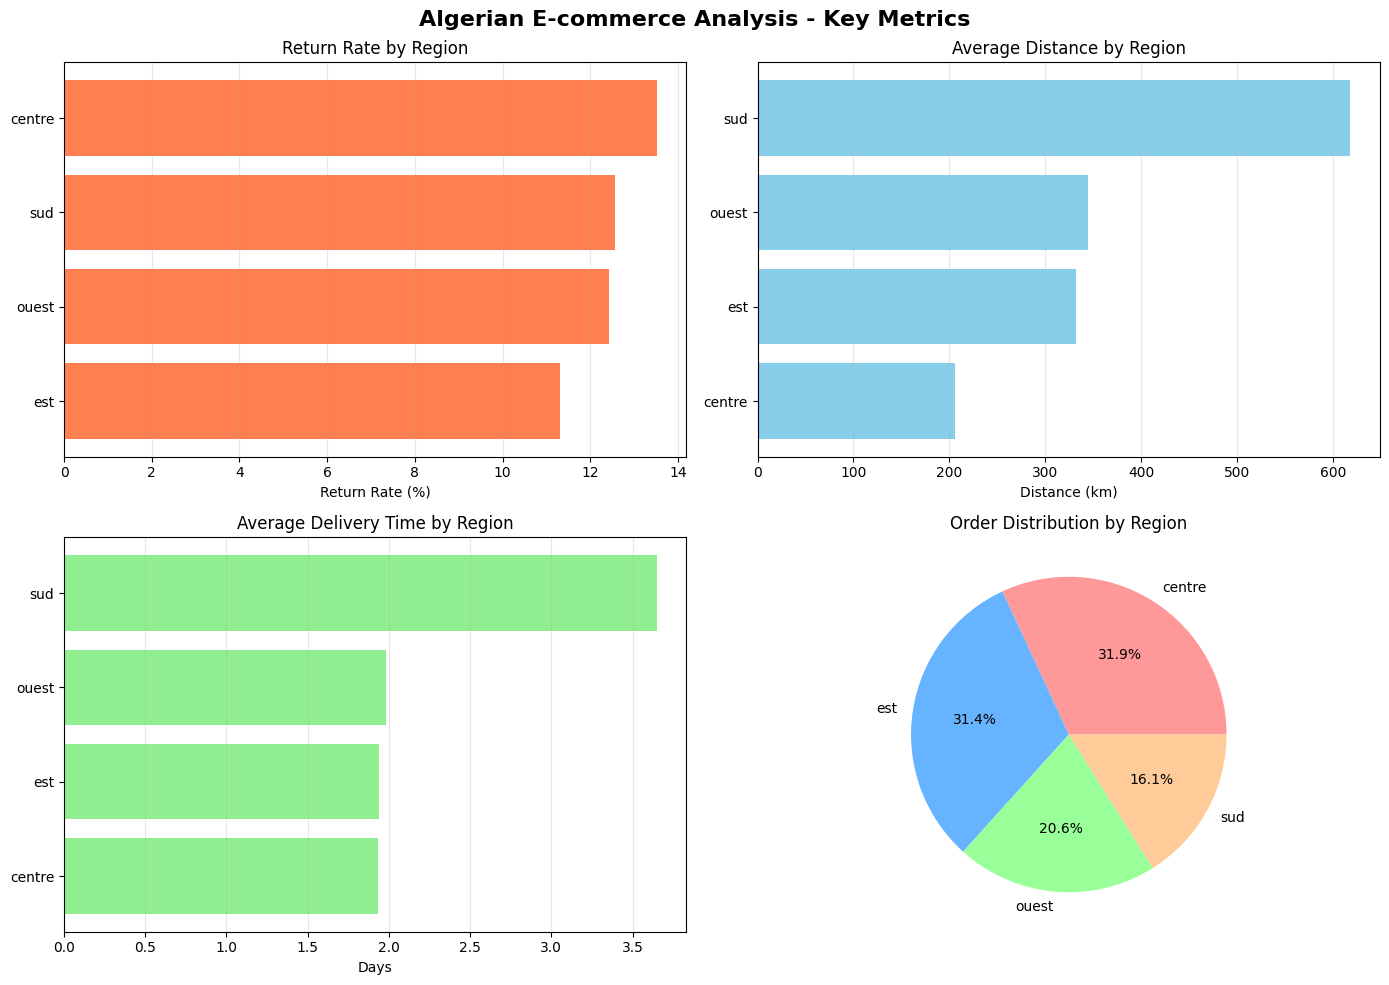

Visualizations created successfully!
✓ Exported as:
  - charts/analysis_key_metrics.png (300 DPI)
  - charts/analysis_key_metrics.pdf
  - charts/chart_return_rate_by_region.png / .pdf
  - charts/chart_avg_distance_by_region.png / .pdf
  - charts/chart_avg_delivery_time_by_region.png / .pdf
  - charts/chart_order_distribution_by_region.png / .pdf


In [136]:
# Create visualizations
output_folder = './charts'  # Save charts in the charts folder

# 1. Return Rate by Region
fig1, ax = plt.subplots(figsize=(10, 6))
return_by_region_sorted = return_by_region.sort_values('Return Rate %', ascending=True)
ax.barh(return_by_region_sorted.index, return_by_region_sorted['Return Rate %'], color='coral')
ax.set_xlabel('Return Rate (%)', fontsize=12)
ax.set_title('Return Rate by Region', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig1.savefig(f'{output_folder}/chart_return_rate_by_region.png', dpi=300, bbox_inches='tight')
fig1.savefig(f'{output_folder}/chart_return_rate_by_region.pdf', bbox_inches='tight')
plt.close(fig1)

# 2. Average Distance by Region (individual chart)
fig2, ax = plt.subplots(figsize=(10, 6))
avg_distance_by_region_sorted = avg_distance_by_region.sort_values('Avg Distance (km)', ascending=True)
ax.barh(avg_distance_by_region_sorted.index, avg_distance_by_region_sorted['Avg Distance (km)'], color='skyblue')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_title('Average Distance per Command by Region', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig2.savefig(f'{output_folder}/chart_avg_distance_by_region.png', dpi=300, bbox_inches='tight')
fig2.savefig(f'{output_folder}/chart_avg_distance_by_region.pdf', bbox_inches='tight')
plt.close(fig2)

# 3. Average Delivery Time by Region (individual chart)
fig3, ax = plt.subplots(figsize=(10, 6))
avg_time_by_region_sorted = avg_time_by_region.sort_values('Avg Time (days)', ascending=True)
ax.barh(avg_time_by_region_sorted.index, avg_time_by_region_sorted['Avg Time (days)'], color='lightgreen')
ax.set_xlabel('Days', fontsize=12)
ax.set_title('Average Delivery Time by Region', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig3.savefig(f'{output_folder}/chart_avg_delivery_time_by_region.png', dpi=300, bbox_inches='tight')
fig3.savefig(f'{output_folder}/chart_avg_delivery_time_by_region.pdf', bbox_inches='tight')
plt.close(fig3)

# 4. Order distribution by Region (pie chart)
fig4, ax = plt.subplots(figsize=(10, 8))
region_counts = df['region'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
ax.pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Order Distribution by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
fig4.savefig(f'{output_folder}/chart_order_distribution_by_region.png', dpi=300, bbox_inches='tight')
fig4.savefig(f'{output_folder}/chart_order_distribution_by_region.pdf', bbox_inches='tight')
plt.close(fig4)

# Combined figure for all charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Algerian E-commerce Analysis - Key Metrics', fontsize=16, fontweight='bold')

# 1. Return Rate by Region
ax1 = axes[0, 0]
ax1.barh(return_by_region_sorted.index, return_by_region_sorted['Return Rate %'], color='coral')
ax1.set_xlabel('Return Rate (%)')
ax1.set_title('Return Rate by Region')
ax1.grid(axis='x', alpha=0.3)

# 2. Average Distance by Region
ax2 = axes[0, 1]
ax2.barh(avg_distance_by_region_sorted.index, avg_distance_by_region_sorted['Avg Distance (km)'], color='skyblue')
ax2.set_xlabel('Distance (km)')
ax2.set_title('Average Distance by Region')
ax2.grid(axis='x', alpha=0.3)

# 3. Average Delivery Time by Region
ax3 = axes[1, 0]
ax3.barh(avg_time_by_region_sorted.index, avg_time_by_region_sorted['Avg Time (days)'], color='lightgreen')
ax3.set_xlabel('Days')
ax3.set_title('Average Delivery Time by Region')
ax3.grid(axis='x', alpha=0.3)

# 4. Order distribution by Region
ax4 = axes[1, 1]
ax4.pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', colors=colors)
ax4.set_title('Order Distribution by Region')

plt.tight_layout()
fig.savefig(f'{output_folder}/analysis_key_metrics.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{output_folder}/analysis_key_metrics.pdf', bbox_inches='tight')

plt.show()

print("Visualizations created successfully!")
print("✓ Exported as:")
print("  - charts/analysis_key_metrics.png (300 DPI)")
print("  - charts/analysis_key_metrics.pdf")
print("  - charts/chart_return_rate_by_region.png / .pdf")
print("  - charts/chart_avg_distance_by_region.png / .pdf")
print("  - charts/chart_avg_delivery_time_by_region.png / .pdf")
print("  - charts/chart_order_distribution_by_region.png / .pdf")

In [137]:
# Create individual visualizations for export
output_folder = './charts'  # Save charts in the charts folder

# Delete old chart files to ensure clean export
chart_files_to_delete = [
    'analysis_key_metrics.png',
    'analysis_key_metrics.pdf',
    'chart_return_rate_by_region.png',
    'chart_return_rate_by_region.pdf',
    'chart_avg_distance_by_region.png',
    'chart_avg_distance_by_region.pdf',
    'chart_avg_delivery_time_by_region.png',
    'chart_avg_delivery_time_by_region.pdf',
    'chart_order_distribution_by_region.png',
    'chart_order_distribution_by_region.pdf',
    'chart_return_rate_same_diff_region.png',
    'chart_return_rate_same_diff_region.pdf'
]
for file in chart_files_to_delete:
    file_path = f'{output_folder}/{file}'
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"  ✓ Deleted old chart file: {file}")
# 1. Return Rate by Region (individual chart)
fig1, ax = plt.subplots(figsize=(10, 6))
return_by_region_sorted = return_by_region.sort_values('Return Rate %', ascending=True)
ax.barh(return_by_region_sorted.index, return_by_region_sorted['Return Rate %'], color='coral')
ax.set_xlabel('Return Rate (%)', fontsize=12)
ax.set_title('Return Rate by Region', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig1.savefig(f'{output_folder}/chart_return_rate_by_region.png', dpi=300, bbox_inches='tight')
fig1.savefig(f'{output_folder}/chart_return_rate_by_region.pdf', bbox_inches='tight')
plt.close(fig1)

# 2. Average Distance by Region (individual chart)
fig2, ax = plt.subplots(figsize=(10, 6))
avg_distance_by_region_sorted = avg_distance_by_region.sort_values('Avg Distance (km)', ascending=True)
ax.barh(avg_distance_by_region_sorted.index, avg_distance_by_region_sorted['Avg Distance (km)'], color='skyblue')
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_title('Average Distance per Command by Region', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig2.savefig(f'{output_folder}/chart_avg_distance_by_region.png', dpi=300, bbox_inches='tight')
fig2.savefig(f'{output_folder}/chart_avg_distance_by_region.pdf', bbox_inches='tight')
plt.close(fig2)

# 3. Average Delivery Time by Region (individual chart)
fig3, ax = plt.subplots(figsize=(10, 6))
avg_time_by_region_sorted = avg_time_by_region.sort_values('Avg Time (days)', ascending=True)
ax.barh(avg_time_by_region_sorted.index, avg_time_by_region_sorted['Avg Time (days)'], color='lightgreen')
ax.set_xlabel('Days', fontsize=12)
ax.set_title('Average Delivery Time by Region', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig3.savefig(f'{output_folder}/chart_avg_delivery_time_by_region.png', dpi=300, bbox_inches='tight')
fig3.savefig(f'{output_folder}/chart_avg_delivery_time_by_region.pdf', bbox_inches='tight')
plt.close(fig3)

# 4. Order distribution by Region (pie chart)
fig4, ax = plt.subplots(figsize=(10, 8))
region_counts = df['region'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
ax.pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Order Distribution by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
fig4.savefig(f'{output_folder}/chart_order_distribution_by_region.png', dpi=300, bbox_inches='tight')
fig4.savefig(f'{output_folder}/chart_order_distribution_by_region.pdf', bbox_inches='tight')
plt.close(fig4)

# 5. Return Rate: Same Region vs Different Region (bar chart)
fig5, ax = plt.subplots(figsize=(10, 6))
same_diff_types = same_diff_region_analysis['Type'].values
same_diff_rates = same_diff_region_analysis['Return Rate %'].values
colors_bar = ['#4CAF50', '#FF6B6B']
bars = ax.bar(same_diff_types, same_diff_rates, color=colors_bar, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Return Rate (%)', fontsize=12)
ax.set_title('Return Rate: Same Region vs Different Region', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, rate in zip(bars, same_diff_rates):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
fig5.savefig(f'{output_folder}/chart_return_rate_same_diff_region.png', dpi=300, bbox_inches='tight')
fig5.savefig(f'{output_folder}/chart_return_rate_same_diff_region.pdf', bbox_inches='tight')
plt.close(fig5)



print("\n")
print("✓ Individual charts exported successfully!")
print(f"\nGenerated visualization files:")
print("  - charts/analysis_key_metrics.png / .pdf")
print("  - charts/chart_return_rate_by_region.png / .pdf")
print("  - charts/chart_avg_distance_by_region.png / .pdf")
print("  - charts/chart_avg_delivery_time_by_region.png / .pdf")
print("  - charts/chart_order_distribution_by_region.png / .pdf")
print("  - charts/chart_return_rate_same_diff_region.png / .pdf")

  ✓ Deleted old chart file: analysis_key_metrics.png
  ✓ Deleted old chart file: analysis_key_metrics.pdf
  ✓ Deleted old chart file: chart_return_rate_by_region.png
  ✓ Deleted old chart file: chart_return_rate_by_region.pdf
  ✓ Deleted old chart file: chart_avg_distance_by_region.png
  ✓ Deleted old chart file: chart_avg_distance_by_region.pdf
  ✓ Deleted old chart file: chart_avg_delivery_time_by_region.png
  ✓ Deleted old chart file: chart_avg_delivery_time_by_region.pdf
  ✓ Deleted old chart file: chart_order_distribution_by_region.png
  ✓ Deleted old chart file: chart_order_distribution_by_region.pdf
  ✓ Deleted old chart file: chart_return_rate_same_diff_region.png
  ✓ Deleted old chart file: chart_return_rate_same_diff_region.pdf


✓ Individual charts exported successfully!

Generated visualization files:
  - charts/analysis_key_metrics.png / .pdf
  - charts/chart_return_rate_by_region.png / .pdf
  - charts/chart_avg_distance_by_region.png / .pdf
  - charts/chart_avg_delivery_t

## 7. Export Results to CSV

In [138]:
# Export analysis results to CSV files and clean up old charts
import os
import shutil

output_folder = './statistics'  # Save statistics in the statistics folder

# Delete old CSV files to ensure clean export
files_to_delete = [
    'analysis_return_rate_by_wilaya.csv',
    'analysis_return_rate_by_region.csv',
    'analysis_avg_distance_by_wilaya.csv',
    'analysis_avg_distance_by_region.csv',
    'analysis_avg_delivery_time_by_wilaya.csv',
    'analysis_avg_delivery_time_by_region.csv',
    'distance_matrix_between_wilayas.csv',
    'analysis_summary.csv',
    'analysis_same_diff_region.csv'
]

for file in files_to_delete:
    file_path = f'{output_folder}/{file}'
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"  ✓ Deleted old CSV file: {file}")



# Export return rate by wilaya
return_by_wilaya.to_csv(f'{output_folder}/analysis_return_rate_by_wilaya.csv')

# Export return rate by region
return_by_region.to_csv(f'{output_folder}/analysis_return_rate_by_region.csv')

# Export average distance by wilaya
avg_distance_by_wilaya.to_csv(f'{output_folder}/analysis_avg_distance_by_wilaya.csv')

# Export average distance by region
avg_distance_by_region.to_csv(f'{output_folder}/analysis_avg_distance_by_region.csv')

# Export average time by wilaya
avg_time_by_wilaya.to_csv(f'{output_folder}/analysis_avg_delivery_time_by_wilaya.csv')

# Export average time by region
avg_time_by_region.to_csv(f'{output_folder}/analysis_avg_delivery_time_by_region.csv')

# Export distance matrix
distance_matrix.to_csv(f'{output_folder}/distance_matrix_between_wilayas.csv')

# Export same/different region analysis
same_diff_region_analysis.to_csv(f'{output_folder}/analysis_same_diff_region.csv', index=False)

# Export summary
summary_export = pd.DataFrame({
    'Metric': ['Overall Return Rate (%)', 'Overall Avg Distance (km)', 'Overall Avg Delivery Time (days)'],
    'Value': [return_rate, avg_distance, avg_time]
})
summary_export.to_csv(f'{output_folder}/analysis_summary.csv', index=False)

print("✓ Results exported successfully!")
print(f"\nGenerated CSV files:")
print("  - statistics/analysis_return_rate_by_wilaya.csv")
print("  - statistics/analysis_return_rate_by_region.csv")
print("  - statistics/analysis_avg_distance_by_wilaya.csv")
print("  - statistics/analysis_avg_distance_by_region.csv")
print("  - statistics/analysis_avg_delivery_time_by_wilaya.csv")
print("  - statistics/analysis_avg_delivery_time_by_region.csv")
print("  - statistics/distance_matrix_between_wilayas.csv")
print("  - statistics/analysis_same_diff_region.csv")
print("  - statistics/analysis_summary.csv")


  ✓ Deleted old CSV file: analysis_return_rate_by_wilaya.csv
  ✓ Deleted old CSV file: analysis_return_rate_by_region.csv
  ✓ Deleted old CSV file: analysis_avg_distance_by_wilaya.csv
  ✓ Deleted old CSV file: analysis_avg_distance_by_region.csv
  ✓ Deleted old CSV file: analysis_avg_delivery_time_by_wilaya.csv
  ✓ Deleted old CSV file: analysis_avg_delivery_time_by_region.csv
  ✓ Deleted old CSV file: distance_matrix_between_wilayas.csv
  ✓ Deleted old CSV file: analysis_summary.csv
  ✓ Deleted old CSV file: analysis_same_diff_region.csv
✓ Results exported successfully!

Generated CSV files:
  - statistics/analysis_return_rate_by_wilaya.csv
  - statistics/analysis_return_rate_by_region.csv
  - statistics/analysis_avg_distance_by_wilaya.csv
  - statistics/analysis_avg_distance_by_region.csv
  - statistics/analysis_avg_delivery_time_by_wilaya.csv
  - statistics/analysis_avg_delivery_time_by_region.csv
  - statistics/distance_matrix_between_wilayas.csv
  - statistics/analysis_same_diff_r